In [1]:
#2021.07.25. SUN
#Team_Complete

## Data Analysis
#00. 패키지 호출
import pandas as pd 
import numpy as np 
import warnings 
import datetime
import matplotlib as mpl
import matplotlib.pylab as plt
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler 
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error

#00-1. warning message ignore 
warnings.filterwarnings(action='ignore')

#00-2. 난수씨드값 지정하기.
np.random.seed(2021)

#00-3. 시각화 옵션 설정하기. 
%matplotlib inline


In [2]:
#01. 데이터셋 전처리하기. 
#(1) 데이터셋 불러오기. 
df_감말랭이_raw = pd.read_csv('../../Data/feature_target/감말랭이.csv', encoding='cp949')

#(2) 원본 보관하기.  
df_감말랭이 = df_감말랭이_raw

#(3) 날짜 컬럼 인덱스로 지정하기. 
df_감말랭이 = df_감말랭이.set_index('date')

#(4) 데이터셋의 target 변수 스케일링하기.
#df_감말랭이['감말랭이_scaling'] = MinMaxScaler().fit_transform(df_감말랭이[['감말랭이']])

#(5) 기존 target 변수 삭제하기.
#del df_감말랭이['감말랭이']

#(6) train, test 데이터셋을 연속적으로 분할하기. 
X_train = df_감말랭이.iloc[0:365,:-1]
y_train = df_감말랭이.iloc[0:365,-1]
X_test  = df_감말랭이.iloc[365:730,:-1]
y_test  = df_감말랭이.iloc[365:730,-1]

#(7) 데이터셋 차원 확인하기.
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((365, 2), (365,), (365, 2), (365,))

In [3]:
#02. rbf SVR(Support Vector Regressor) 모델로 학습 및 평가하기. 
#(1) 모델 생성하기. 
rbf_svr = SVR()

#(2) 하이퍼 파라미터 확인하기. 
rbf_svr.get_params()

{'C': 1.0,
 'cache_size': 200,
 'coef0': 0.0,
 'degree': 3,
 'epsilon': 0.1,
 'gamma': 'scale',
 'kernel': 'rbf',
 'max_iter': -1,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [4]:
#(3) GridSearch를 위한 하이퍼파라미터 값 지정하기. (recycle)
rbf_svm_params = {
    'C'       : [0.125, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3],
    'epsilon' : [0.125, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5]
}

#(4) GridsearchCV() 메서드를 이용해 훈련 모델 할당하기. 
gscv_rbf_svr = GridSearchCV(rbf_svr, param_grid=rbf_svm_params, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)

#(5) 모델 학습하기. 
gscv_rbf_svr.fit(X_train,y_train)

GridSearchCV(cv=10, estimator=SVR(), n_jobs=-1,
             param_grid={'C': [0.125, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2,
                               2.25, 2.5, 2.75, 3],
                         'epsilon': [0.125, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75,
                                     2, 2.25, 2.5]},
             scoring='neg_mean_squared_error')

In [5]:
#(6) 최적 하이퍼 파라미터 확인하기. 
gscv_rbf_svr.best_params_

{'C': 0.125, 'epsilon': 0.75}

In [6]:
#(7) 최적 파라미터에 대한 평가 점수 확인하기. 
np.abs(gscv_rbf_svr.best_score_)

3.9359697859968845

In [7]:
#(8) test 데이터셋으로 모델 예측 및 평가하기. 
#①R-squared
gscv_rbf_svr_fit = gscv_rbf_svr.best_estimator_
rbf_svr_pred     = gscv_rbf_svr_fit.predict(X_test)
rbf_svr_r2       = r2_score(y_test,rbf_svr_pred)
rbf_svr_r2

0.350864821574318

In [8]:
#②MSE 
rbf_svr_mse = mean_squared_error(y_test,rbf_svr_pred)
rbf_svr_mse

2.0294536029459405

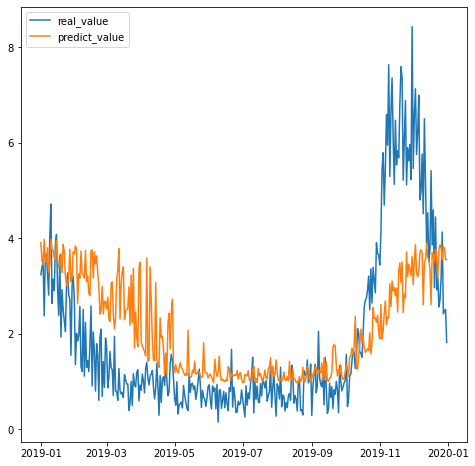

In [9]:
#(9) 예측값 시각화하기. 
test_date = df_감말랭이_raw.iloc[365:730,0]
test_date = test_date.astype('str')
test_date = pd.to_datetime(test_date)
plt.figure(figsize=(8,8))
plt.plot(test_date, y_test, label='real_value')
plt.plot(test_date, rbf_svr_pred, label='predict_value')
plt.legend(loc='upper left')
plt.show()

In [10]:
#03. linear SVR(Support Vector Regressor) 모델로 학습 및 평가하기. 
#(1) 모델 생성하기.
linear_svr = SVR(kernel='linear')

#(2)
linear_svr.get_params()

{'C': 1.0,
 'cache_size': 200,
 'coef0': 0.0,
 'degree': 3,
 'epsilon': 0.1,
 'gamma': 'scale',
 'kernel': 'linear',
 'max_iter': -1,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [11]:
#(3) GridSearch를 위한 하이퍼파라미터 값 지정하기. (recycle)
linear_svm_params = {
    'C'       : [3, 3.25, 3.5, 3.75, 4],
    'epsilon' : [0.125, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5]
}

#(4) GridsearchCV() 메서드를 이용해 훈련 모델 할당하기. 
gscv_linear_svr = GridSearchCV(linear_svr, param_grid=linear_svm_params, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)

#(5) 모델 학습하기. 
gscv_linear_svr.fit(X_train,y_train)

GridSearchCV(cv=10, estimator=SVR(kernel='linear'), n_jobs=-1,
             param_grid={'C': [3, 3.25, 3.5, 3.75, 4],
                         'epsilon': [0.125, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75,
                                     2, 2.25, 2.5]},
             scoring='neg_mean_squared_error')

In [12]:
#(6) 최적 하이퍼 파라미터 확인하기. 
gscv_linear_svr.best_params_

{'C': 3.75, 'epsilon': 1}

In [13]:
#(7) 최적 파라미터에 대한 평가 점수 확인하기. 
np.abs(gscv_linear_svr.best_score_)

3.47376946475237

In [14]:
#(8) test 데이터셋으로 모델 예측 및 평가하기. 
#①R-squared
gscv_linear_svr_fit = gscv_linear_svr.best_estimator_
linear_svr_pred     = gscv_linear_svr_fit.predict(X_test)
linear_svr_r2       = r2_score(y_test,linear_svr_pred)
linear_svr_r2

0.3232464205226663

In [15]:
#②MSE 
linear_svr_mse = mean_squared_error(y_test,linear_svr_pred)
linear_svr_mse

2.1157996605695875

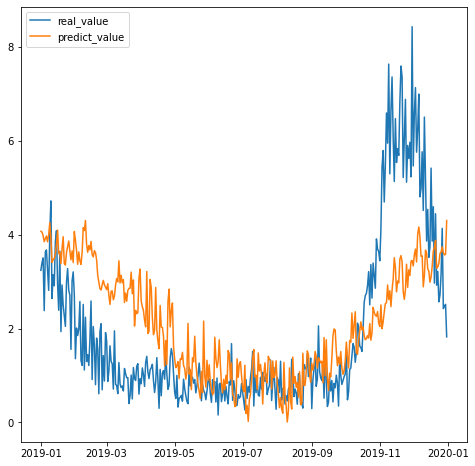

In [16]:
#(9) 예측값 시각화하기. 
plt.figure(figsize=(8,8))
plt.plot(test_date, y_test, label='real_value')
plt.plot(test_date, linear_svr_pred, label='predict_value')
plt.legend(loc='upper left')        
plt.show()

In [17]:
#04. poly SVR(Support Vector Regressor) 모델로 학습 및 평가하기. 
#(1) 모델 생성하기. 
poly_svr = SVR(kernel='poly')

#(2) 하이퍼 파라미터 확인하기. 
poly_svr.get_params()

{'C': 1.0,
 'cache_size': 200,
 'coef0': 0.0,
 'degree': 3,
 'epsilon': 0.1,
 'gamma': 'scale',
 'kernel': 'poly',
 'max_iter': -1,
 'shrinking': True,
 'tol': 0.001,
 'verbose': False}

In [18]:
#(3) GridSearch를 위한 하이퍼파라미터 값 지정하기. (recycle)
poly_svm_params = {
    'C'       : [0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5, 2.75, 3, 3.25, 3.5, 3.75, 4],
    'epsilon' : [0.125, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5],
    'degree'  : [3, 4, 5]
}

#(4) GridsearchCV() 메서드를 이용해 훈련 모델 할당하기. 
gscv_poly_svr = GridSearchCV(poly_svr, param_grid=poly_svm_params, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)

#(5) 모델 학습하기. 
gscv_poly_svr.fit(X_train,y_train)

GridSearchCV(cv=10, estimator=SVR(kernel='poly'), n_jobs=-1,
             param_grid={'C': [0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.25, 2.5,
                               2.75, 3, 3.25, 3.5, 3.75, 4],
                         'degree': [3, 4, 5],
                         'epsilon': [0.125, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75,
                                     2, 2.25, 2.5]},
             scoring='neg_mean_squared_error')

In [19]:
#(6) 최적 하이퍼 파라미터 확인하기. 
gscv_poly_svr.best_params_

{'C': 1.75, 'degree': 3, 'epsilon': 1.5}

In [20]:
#(7) 최적 파라미터에 대한 평가 점수 확인하기. 
np.abs(gscv_poly_svr.best_score_)

4.148161129785081

In [21]:
#(8) test 데이터셋으로 모델 예측 및 평가하기. 
#①R-squared
gscv_poly_svr_fit = gscv_poly_svr.best_estimator_
poly_svr_pred     = gscv_poly_svr_fit.predict(X_test)
poly_svr_r2       = r2_score(y_test,poly_svr_pred)
poly_svr_r2

0.16836796240530738

In [22]:
#②MSE 
poly_mse = mean_squared_error(y_test,poly_svr_pred)
poly_mse

2.60001104718291

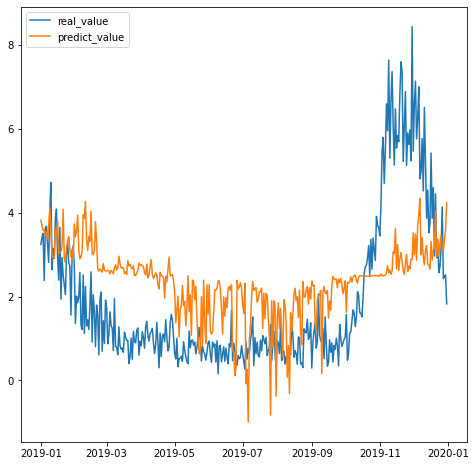

In [23]:
#(9) 예측값 시각화하기. 
plt.figure(figsize=(8,8))
plt.plot(test_date, y_test, label='real_value')
plt.plot(test_date, poly_svr_pred, label='predict_value')
plt.legend(loc='upper left')        
plt.show()